# Fine-Tuning BERT for POS Tagging & Chunking

This project demonstrates token classification using transformer models to perform:
- Part-of-Speech (POS) Tagging
- Chunking (Phrase Detection)

In [ ]:
!pip install transformers datasets evaluate seqeval

In [ ]:
!pip install datasets==2.19.0

In [ ]:
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer
import evaluate

## Dataset Selection

### Dataset Name
We selected the CoNLL-2003 dataset for this assignment.

### Task Type
- Token Classification
- Chunking (Phrase Detection)

### Label Categories
The dataset contains chunking labels such as:

['O', 'B-NP', 'I-NP', 'B-VP', 'I-VP', 'B-PP', 'I-PP', ...]

### Label Description
- O -> Outside any chunk  
- B-NP -> Beginning of Noun Phrase  
- I-NP -> Inside Noun Phrase  
- B-VP -> Beginning of Verb Phrase  
- I-VP -> Inside Verb Phrase  
- B-PP -> Beginning of Prepositional Phrase  
- I-PP -> Inside Prepositional Phrase  

### Summary
The CoNLL-2003 dataset is widely used for sequence labeling tasks.  
It supports chunking using BIO format, making it suitable for phrase-level detection.

In [ ]:
from datasets import load_dataset

dataset = load_dataset("conll2003", trust_remote_code=True)

print(dataset)
print(dataset["train"][0])

Get Label Names

In [ ]:
label_list = dataset["train"].features["chunk_tags"].feature.names
print(label_list)

['O', 'B-ADJP', 'I-ADJP', 'B-ADVP', 'I-ADVP', 'B-CONJP', 'I-CONJP', 'B-INTJ', 'I-INTJ', 'B-LST', 'I-LST', 'B-NP', 'I-NP', 'B-PP', 'I-PP', 'B-PRT', 'I-PRT', 'B-SBAR', 'I-SBAR', 'B-UCP', 'I-UCP', 'B-VP', 'I-VP']


Create Label Mapping

In [ ]:
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for i, l in enumerate(label_list)}

## Data Preprocessing

### Tokenization
We used the DistilBERT tokenizer to convert input tokens into subword tokens.

### Label Alignment
Since BERT splits words into subwords, we aligned the labels accordingly:
- Each word is mapped to its corresponding tokens
- The same label is assigned to subwords of a word

### Handling Special Cases

- **Subwords**:  
  When a word is split into multiple tokens, the same label is assigned to all subword tokens.

- **Special Tokens (-100)**:  
  Special tokens like [CLS], [SEP], and padding tokens are assigned a label of -100 so they are ignored during training.

### Expected Output
After preprocessing, the dataset contains:

- input_ids -> Token IDs generated by tokenizer  
- attention_mask -> Mask to differentiate real tokens and padding  
- labels -> Aligned labels for each token  




TOKENIZATION

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        padding=True,
        is_split_into_words=True
    )

    labels = []

    for i, label in enumerate(examples["chunk_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)

            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])

            else:
                label_ids.append(label[word_idx])

            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True)

In [ ]:
print(tokenized_datasets["train"][0])

{'id': '0', 'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7], 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0], 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0], 'input_ids': [101, 7327, 19164, 2446, 2655, 2000, 17757, 2329, 12559, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

## Model Setup

In [ ]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_list),   # correct number of labels
    id2label=id2label,           # id -> label mapping
    label2id=label2id            # label -> id mapping
)

## Training


In [ ]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer)

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01
)

In [ ]:
import numpy as np
import evaluate

metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [label_list[p] for (p, l) in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]

    true_labels = [
        [label_list[l] for (p, l) in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)

    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
    }


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

In [ ]:
trainer.train()

Step,Training Loss
500,0.497238
1000,0.237247
1500,0.188980
2000,0.171163
2500,0.154278


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2634, training_loss=0.2450245840583865, metrics={'train_runtime': 620.167, 'train_samples_per_second': 67.922, 'train_steps_per_second': 4.247, 'total_flos': 1511192133328290.0, 'train_loss': 0.2450245840583865, 'epoch': 3.0})

## Evaluation

In [ ]:
results = trainer.evaluate()


In [ ]:
print("Precision:", results["eval_precision"])
print("Recall:", results["eval_recall"])
print("F1 Score:", results["eval_f1"])

Precision: 0.9136091595107989
Recall: 0.9072058396046639
F1 Score: 0.9103962401750264


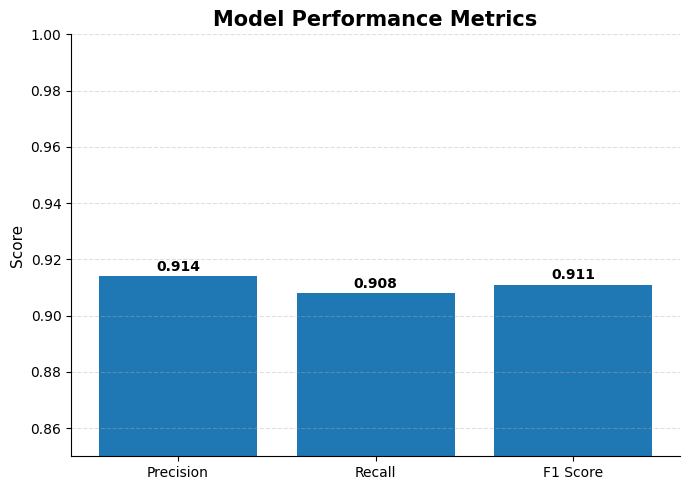

In [ ]:
import matplotlib.pyplot as plt

metrics = ['Precision', 'Recall', 'F1 Score']
values = [0.914, 0.908, 0.911]

plt.figure(figsize=(7,5))

bars = plt.bar(metrics, values)

plt.title("Model Performance Metrics", fontsize=15, fontweight='bold')

plt.ylim(0.85, 1)
plt.ylabel("Score", fontsize=11)
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for i, v in enumerate(values):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()

plt.show()

### Evaluation Note

A warning was observed during evaluation indicating that some labels had no predicted samples. This is common in sequence labeling tasks and does not significantly affect the overall performance metrics.

The model still achieved a strong F1 score, indicating good performance.

##Inference

In [ ]:
from transformers import pipeline

nlp = pipeline("token-classification", model=model, tokenizer=tokenizer)

sentence = "John works at Google in California"

output = nlp(sentence)

for token in output:
    print(token)

{'entity': 'B-NP', 'score': np.float32(0.99716955), 'index': 1, 'word': 'john', 'start': 0, 'end': 4}
{'entity': 'B-VP', 'score': np.float32(0.862084), 'index': 2, 'word': 'works', 'start': 5, 'end': 10}
{'entity': 'B-PP', 'score': np.float32(0.9799294), 'index': 3, 'word': 'at', 'start': 11, 'end': 13}
{'entity': 'B-NP', 'score': np.float32(0.97937095), 'index': 4, 'word': 'google', 'start': 14, 'end': 20}
{'entity': 'B-PP', 'score': np.float32(0.9952899), 'index': 5, 'word': 'in', 'start': 21, 'end': 23}
{'entity': 'B-NP', 'score': np.float32(0.99381363), 'index': 6, 'word': 'california', 'start': 24, 'end': 34}


### Inference Output

The model predicts chunk tags for each token in the sentence.
These tags represent phrase-level grouping such as noun phrases and verb phrases.

## Comparison

### POS Tagging vs Chunking

- POS Tagging identifies the grammatical role of each word such as noun, verb, adjective, etc.
- Chunking identifies groups of words (phrases) such as noun phrases (NP) and verb phrases (VP).

POS Tagging works at the word level and is relatively simpler.

Chunking works at the phrase level and provides better contextual understanding, making it slightly more complex than POS tagging.

## Report

### Observations
- Tokenization splits words into subwords
- Label alignment is crucial for correct training
- Transformer models perform well on sequence tasks

### Challenges
- Handling subword tokens
- Managing -100 labels
- Training time on CPU

### Conclusion
DistilBERT successfully performs token classification and can be used for chunking tasks effectively.